# Modelos Multimodales
### Máster en IA y Computación Cuántica Aplicada a los Mercados Financieros (MIAX)

---

- **Autor:** Pablo Hernández Cámara
- **Contacto:** [pablo.hernandez-camara@uv.es](mailto:pablo.hernandez-camara@uv.es)
- **Notebook:** Utilizando un VLM (Qwen)

En este notebook vamos a utilizar **Qwen2.5-VL-3B-Instruct** para trabajar con imágenes y texto de forma conjunta. Recordad que VQA (Visual Question Answering)** consiste en proporcionar una imagen y una pregunta en lenguaje natural para que el modelo genere una respuesta basada en el contenido visual.

In [1]:
!pip install qwen-vl-utils[decord]==0.0.8

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 106.3 MB/s eta 0:00:00


In [2]:
from PIL import Image
import requests

# Carga del modelo

Vamos a utilizar **Qwen2.5-VL-3B-Instruct**, una versión relativamente compacta de la familia Qwen-VL. El sufijo `VL` significa **Vision-Language**: el modelo está diseñado para trabajar conjuntamente con información visual y lingüística. `device_map="auto"` permite a 🤗 Transformers decidir dónde colocar el modelo. En un entorno con GPU, como Colab, esto permite aprovechar la aceleración disponible.

**Coste computacional:** cargar un modelo multimodal requiere memoria de GPU. El tiempo de inferencia también dependerá de la resolución de la imagen y del número de tokens generados.

In [3]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from qwen_vl_utils import process_vision_info

model = Qwen2_5_VLForConditionalGeneration.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct", torch_dtype="auto", device_map="auto")
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-3B-Instruct")

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Descargamos una imagen de ejemplo. Reducir su tamaño facilita la demostración y limita el coste computacional. En aplicaciones reales conviene estudiar el compromiso entre **resolución, coste y calidad de la respuesta**.

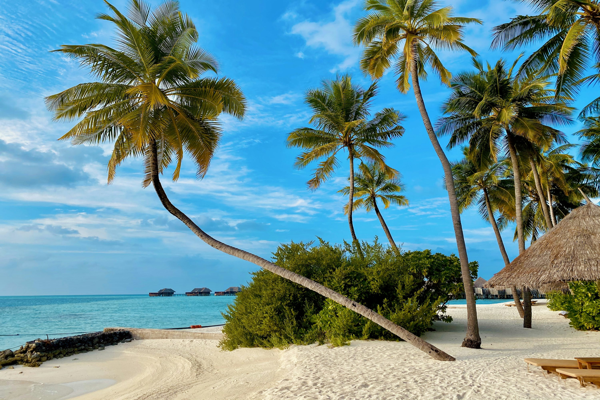

In [4]:
url = "https://images.unsplash.com/photo-1590523741831-ab7e8b8f9c7f?fm=jpg&q=60&w=3000&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mnx8cGxheWFzfGVufDB8fDB8fHww"
image = Image.open(requests.get(url, stream=True).raw).resize((600,400))
image

La estructura de `messages` sigue el formato de conversación utilizado por los modelos de Qwen. Observa que el mensaje contiene **dos elementos de contenido**:

- una imagen (`type="image"`)
- una pregunta textual (`type="text"`)

Esto es precisamente lo que hace que la consulta sea multimodal.

In [5]:
messages = [{"role": "user",
             "content": [{"type":"image", "image":image},
                         {"type": "text", "text": "Describe this image."}]}]

Hay tres pasos conceptualmente importantes:

1. **Chat template:** convierte la conversación a la representación textual que espera Qwen.
2. **Procesamiento visual:** transforma la imagen en las entradas visuales necesarias.
3. **Processor:** combina texto e imagen y construye los tensores que se envían al modelo.

In [6]:
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
print(text)

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Describe this image.<|im_end|>
<|im_start|>assistant



In [7]:
image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(text=[text],images=image_inputs,videos=video_inputs,padding=True,return_tensors="pt").to('cuda')

`model.generate()` realiza la generación autoregresiva: a partir de las entradas, el modelo va produciendo los tokens de la respuesta. Después eliminamos los tokens correspondientes a la entrada para quedarnos únicamente con la respuesta generada.



In [8]:
generated_ids = model.generate(**inputs, max_new_tokens=256)
generated_ids_trimmed = [out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)
print(output_text)

['The image depicts a serene tropical beach scene. The foreground is dominated by a large, curved palm tree with its long, slender trunk and lush green fronds. The beach is sandy and appears to be quite wide, with the ocean visible in the background. Several smaller palm trees and other tropical vegetation are scattered around the area, adding to the lush greenery. In the distance, there are a few boats anchored near the shore, and a few thatched-roof structures, possibly part of a resort or beachfront property. The sky is clear with a few scattered clouds, suggesting a sunny day. The overall atmosphere is calm and inviting, typical of a tropical paradise.']


In [9]:
output_text[0]

'The image depicts a serene tropical beach scene. The foreground is dominated by a large, curved palm tree with its long, slender trunk and lush green fronds. The beach is sandy and appears to be quite wide, with the ocean visible in the background. Several smaller palm trees and other tropical vegetation are scattered around the area, adding to the lush greenery. In the distance, there are a few boats anchored near the shore, and a few thatched-roof structures, possibly part of a resort or beachfront property. The sky is clear with a few scattered clouds, suggesting a sunny day. The overall atmosphere is calm and inviting, typical of a tropical paradise.'

Una de las ventajas de VQA es que **la misma imagen puede utilizarse para tareas diferentes simplemente cambiando el prompt**. Por ejemplo, podemos pasar de una descripción abierta a una pregunta de respuesta corta.

In [12]:
messages = [{"role": "user",
             "content": [{"type":"image", "image":image},
                         {"type": "text", "text": "Is there any boat in the image?"}]}]

text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text],images=image_inputs,videos=video_inputs,padding=True,return_tensors="pt").to('cuda')

generated_ids = model.generate(**inputs, max_new_tokens=4)
generated_ids_trimmed = [out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)
print(output_text[0])

No, there is


# VQA con varias imágenes

Algunos modelos multimodales también pueden recibir **más de una imagen dentro del mismo mensaje**. Esto permite plantear tareas como:

- comparar imágenes,
- detectar cambios,
- encontrar elementos comunes,
- ordenar imágenes según algún criterio,
- o analizar una secuencia de documentos.

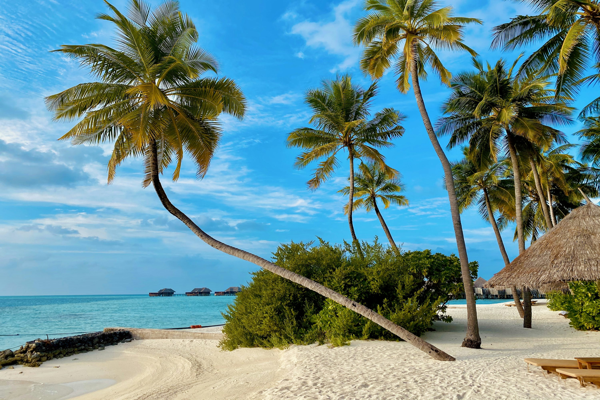

In [ ]:
url = "https://images.unsplash.com/photo-1590523741831-ab7e8b8f9c7f?fm=jpg&q=60&w=3000&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mnx8cGxheWFzfGVufDB8fDB8fHww"
image = Image.open(requests.get(url, stream=True).raw).resize((600,400))
image

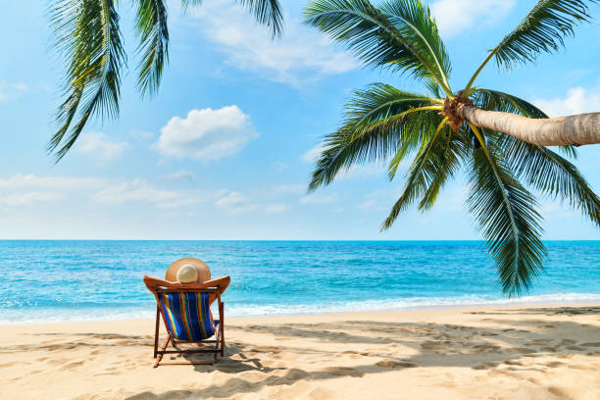

In [ ]:
url = "https://media.istockphoto.com/id/1160946557/es/foto/vista-trasera-de-joven-hermosa-mujer-tomar-el-sol-y-relajarse-en-la-playa-tropical-con-espacio.jpg?s=612x612&w=0&k=20&c=dAYuuxO-gzGGabex5UNVIEDnAM9aYRV1ZA14hzgHSSg="
image_2 = Image.open(requests.get(url, stream=True).raw).resize((600,400))
image_2

In [ ]:
messages = [{"role": "user",
             "content": [{"type":"image", "image":image},
                         {"type":"image", "image":image_2},
                         {"type": "text", "text": "Describe the similarities and diferences between the tow images."}]}]

text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text],images=image_inputs,videos=video_inputs,padding=True,return_tensors="pt").to('cuda')

generated_ids = model.generate(**inputs, max_new_tokens=256)
generated_ids_trimmed = [out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)
print(output_text[0])

Both images depict a tropical beach setting with palm trees, clear blue skies, and calm waters. However, there are some differences:

1. **Objects Present**:
   - **Image 1**: A wooden deck chair with a person sitting on it, wearing a hat.
   - **Image 2**: No visible objects or people.

2. **Background Elements**:
   - **Image 1**: A small boat in the distance on the water.
   - **Image 2**: No boats or other watercraft visible.

3. **Shade and Shadows**:
   - **Image 1**: The deck chair is casting a shadow on the sand, indicating the position of the sun.
   - **Image 2**: There are no shadows visible, suggesting the sun might be higher in the sky or the angle of light is different.

4. **Overall Composition**:
   - **Image 1**: The deck chair is positioned closer to the foreground, making it more prominent.
   - **Image 2**: The palm trees and beach are more spread out, creating a wider view of the scene.

These differences highlight the varied compositions and focal points within ea

In [ ]:
messages = [{"role": "user",
             "content": [{"type":"image", "image":image},
                         {"type":"image", "image":image},
                         {"type": "text", "text": "Analyze the two images and if you found any differences describe them."}]}]

text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text],images=image_inputs,videos=video_inputs,padding=True,return_tensors="pt").to('cuda')

generated_ids = model.generate(**inputs, max_new_tokens=256)
generated_ids_trimmed = [out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)
print(output_text[0])

The two images provided are identical in content, depicting a serene beach scene with palm trees, a clear blue sky, and a calm ocean. There are no noticeable differences between the two images; they appear to be the same photograph taken from the same angle and location.


La entrada visual no obliga a utilizar inglés. Podemos formular la pregunta en español u otros idiomas.

In [ ]:
messages = [{"role": "user",
             "content": [{"type":"image", "image":image},
                         {"type": "text", "text": "Razona donde puede estar hecha esta imagen."}]}]

text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text],images=image_inputs,videos=video_inputs,padding=True,return_tensors="pt").to('cuda')

generated_ids = model.generate(**inputs, max_new_tokens=256)
generated_ids_trimmed = [out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)
print(output_text[0])

Esta imagen parece haber sido tomada en las Maldivas, una isla tropical conocida por sus playas de arena blanca y aguas cristalinas. Las características de la imagen incluyen:

1. Playa con arena blanca.
2. Palmeras de coco típicas de las Maldivas.
3. Agua azul profundo.
4. Bungalows o estructuras de madera típicas de las islas maldivas.
5. Un pequeño barco en el horizonte.

Estos elementos juntos sugieren que la imagen fue tomada en una isla de las Maldivas, posiblemente en un destino turístico conocido por su belleza natural y su clima tropical.


# Documentos e imágenes: una aproximación al OCR

Los modelos Vision-Language pueden utilizarse también para **extraer y comprender información presente en documentos**. En este ejemplo no solo preguntamos "¿qué texto aparece?", sino que formulamos una pregunta sobre el contenido del documento. Esto ilustra una diferencia importante:

- **OCR clásico:** intenta transcribir el texto.
- **VLM:** puede combinar lectura visual + comprensión + respuesta a preguntas.

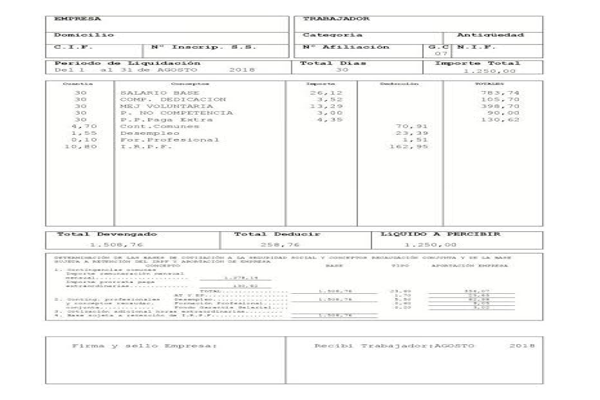

In [ ]:
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTorqnFu6NawLJ692CmHgRowX_z3MU2om_k7YzJbhGP6ZxGJk1qvUn8K2w&s=10"
image_doc = Image.open(requests.get(url, stream=True).raw)#.resize((600,400))
image_doc

In [ ]:
messages = [{"role": "user",
             "content": [{"type":"image", "image":image_doc},
                         {"type": "text", "text": "Cual es la base IRPF?"}]}]

text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text],images=image_inputs,videos=video_inputs,padding=True,return_tensors="pt").to('cuda')

generated_ids = model.generate(**inputs, max_new_tokens=256)
generated_ids_trimmed = [out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)
print(output_text[0])

Lo siento, pero no puedo proporcionar información sobre la base IRPF (Impuesto sobre la Renta de las Personas Físicas) basada en un documento específico como el que has incluido. La base IRPF se calcula teniendo en cuenta varios factores, incluyendo:

1. El ingreso neto bruto del trabajador.
2. La renta imponible.
3. Las deducciones y exclusiones permitidas.

Para obtener una respuesta precisa, necesitaría ver el documento original o tener acceso a los detalles específicos del ingreso y deducciones mencionados en él. Si tienes más información sobre el documento, estaré encantado de ayudarte a analizarla y proporcionar una respuesta más precisa.


¿Qué ocurre si degradamos la imagen? Ahora reducimos artificialmente la resolución del documento. Este experimento es especialmente interesante para entender que la capacidad de un modelo multimodal **no implica que sea inmune a la calidad de la entrada**. En un contexto financiero, esto es especialmente relevante: un error al leer un número, un porcentaje o una fecha puede cambiar completamente el significado de un documento.

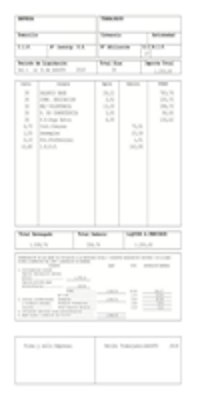

In [ ]:
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTorqnFu6NawLJ692CmHgRowX_z3MU2om_k7YzJbhGP6ZxGJk1qvUn8K2w&s=10"
image_doc_2 = Image.open(requests.get(url, stream=True).raw).resize((100,200)).resize((200,400))
image_doc_2

In [ ]:
messages = [{"role": "user",
             "content": [{"type":"image", "image":image_doc_2},
                         {"type": "text", "text": "Cual es la base IRPF?"}]}]

text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text],images=image_inputs,videos=video_inputs,padding=True,return_tensors="pt").to('cuda')

generated_ids = model.generate(**inputs, max_new_tokens=256)
generated_ids_trimmed = [out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
output_text = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)
print(output_text[0])

La base imponible del Impuesto sobre la Renta de las Personas Físicas (IRPF) se calcula teniendo en cuenta los siguientes elementos:

1. Salarios y pensiones: Se incluyen todos los ingresos que se obtengan durante el año, como salarios, pensiones, jubilaciones, prestaciones por desempleo, etc.

2. Ganancias patrimoniales: Incluye ganancias obtenidas por la venta de bienes o activos, intereses, dividendos, etc.

3. Ganancias laborales: Se refiere a las ganancias obtenidas por trabajos remunerados, independientemente de su origen (doméstico, profesional, etc.).

4. Ganancias de la propiedad: Incluye ganancias obtenidas por la venta de bienes inmuebles, acciones, bonos, etc.

5. Ganancias de la inversión: Se refiere a las ganancias obtenidas por inversiones financieras, como bonos, acciones, etc.

6. Ganancias de la explotación: Se refiere a las ganancias obtenidas por la explotación de bienes inmuebles, como locales comerciales, casas, etc.

7. Ganancias


Tips extra:
- Comprobar valores de parametros de generacion del modelo. Podemos jugar con ellos, pero los mejores serán los que recomiendan ellos.

- Algunos modelos pueden pensar, que no es más que pedirle que razone antes de dar una respuesta final. Suele tardar mucho más ya que el modelo genera muchos más tokens (pueden ser visibles o no).

- Normalmente, si queremos forzar una salida de cierta forma, lo mejor es pedirle un json. Hay librerias para forzarlo.

- Hay librerias para ponerlo en produccion y recoger datos de todas las interacciones (MLFlow por ejemplo).